# Notebook 3 — Live Dashboard & EWS Integration — Completed
Source: DigiHaz Module 7 Topic 4 `03_dashboard_ews_integration.ipynb`.

The source explicitly allows a **synthetic fallback** when InfluxDB credentials are unavailable. This execution uses that mode.


In [1]:
from datetime import datetime, timezone
import numpy as np, pandas as pd, matplotlib.pyplot as plt
USE_REAL_DATA=False
print('No InfluxDB credentials supplied → synthetic fallback')


No InfluxDB credentials supplied → synthetic fallback


In [2]:
def generate_synthetic(hours=24):
    np.random.seed(7); n=hours*12; end=datetime.now(timezone.utc); times=pd.date_range(end=end,periods=n,freq='5min'); t=np.arange(n)*5/60; rows=[]
    scenarios={
    'site_alpha':dict(tilt=.5+np.random.normal(0,.2,n),press=1013+1.5*np.sin(2*np.pi*t/12)+np.random.normal(0,.4,n),soil=35+5*np.sin(2*np.pi*t/24)+np.random.normal(0,1,n)),
    'site_beta':dict(tilt=.5+np.random.normal(0,.2,n),press=1013-10*np.exp(-((t-12)/4)**2)+np.random.normal(0,.4,n),soil=40+50*np.exp(-((t-14)/6)**2)+np.random.normal(0,1.5,n)),
    'site_gamma':dict(tilt=.5+.12*t+np.random.normal(0,.2,n),press=1013+1.5*np.sin(2*np.pi*t/12)+np.random.normal(0,.4,n),soil=40+30*np.exp(-((t-18)/8)**2)+np.random.normal(0,1,n)),
    'site_delta':dict(tilt=.5+.05*t+np.where(t>18,12*(1-np.exp(-(t-18))),0)+np.random.normal(0,.3,n),press=1013-12*np.exp(-((t-10)/5)**2)+np.random.normal(0,.4,n),soil=40+55*np.exp(-((t-14)/6)**2)+np.random.normal(0,1.5,n))}
    for site,d in scenarios.items():
        d['soil']=np.clip(d['soil'],0,100)
        for i in range(n): rows.append({'time':times[i],'site':site,'tilt_deg':d['tilt'][i],'press_hpa':d['press'][i],'soil_pct':d['soil'][i]})
    return pd.DataFrame(rows)
df=generate_synthetic(); print('rows',len(df),'sites',sorted(df.site.unique()))


rows 1152 sites ['site_alpha', 'site_beta', 'site_delta', 'site_gamma']


## Local mirror of the Grafana dashboard


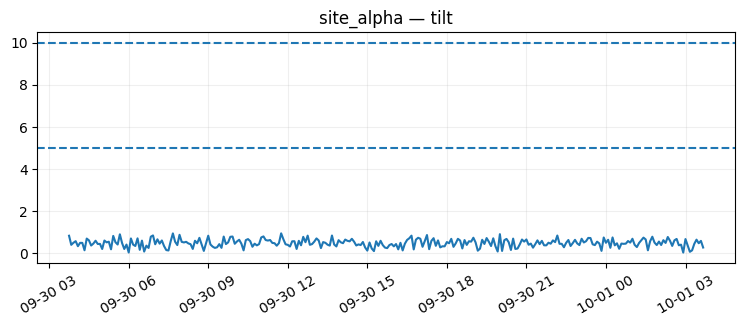

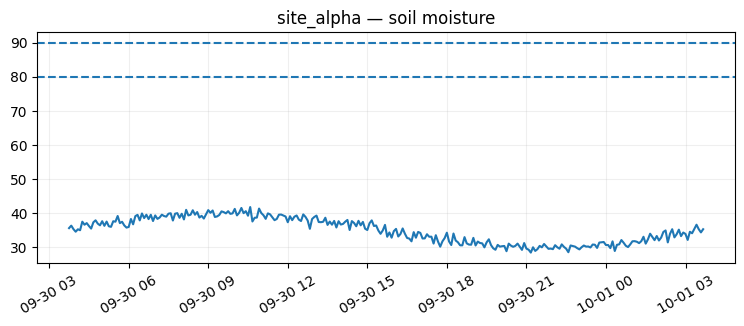

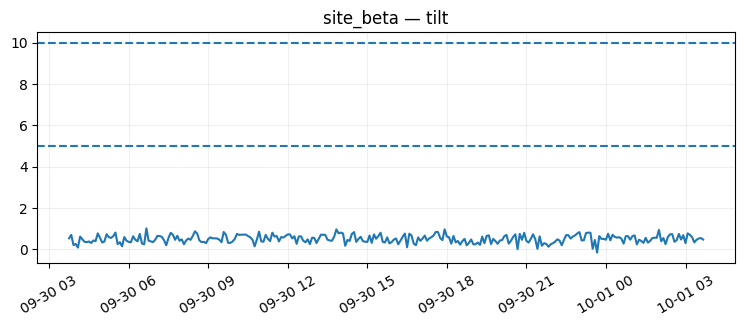

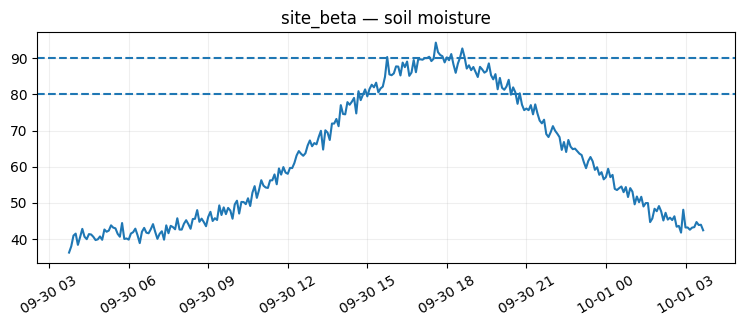

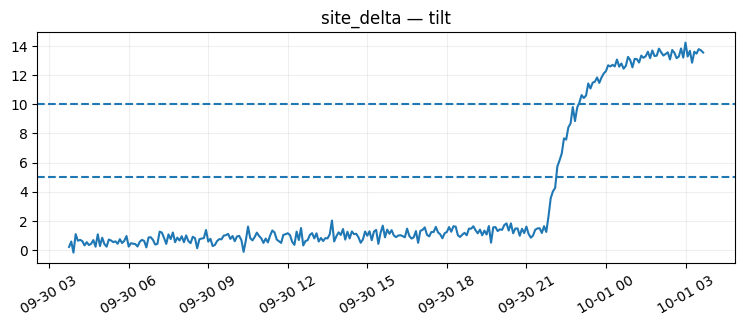

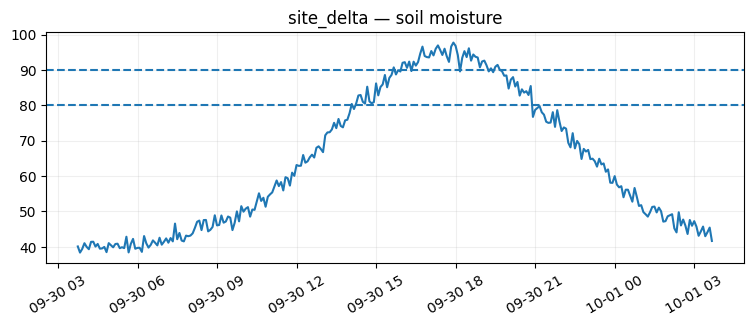

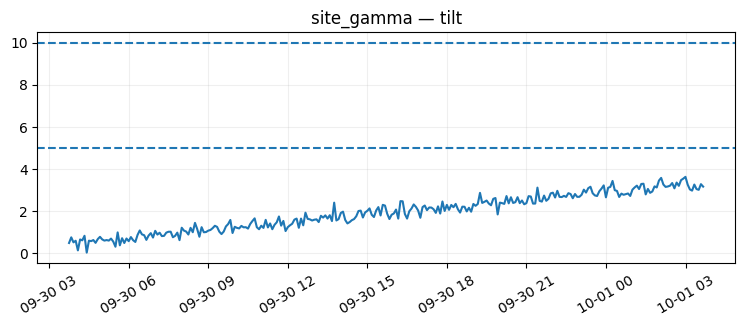

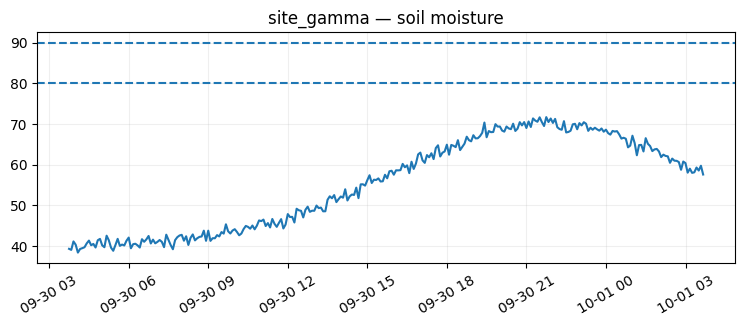

In [3]:
for site in sorted(df.site.unique()):
    sd=df[df.site==site]
    plt.figure(figsize=(9,3)); plt.plot(sd.time,sd.tilt_deg); plt.axhline(5,ls='--'); plt.axhline(10,ls='--'); plt.title(site+' — tilt'); plt.xticks(rotation=30); plt.grid(alpha=.2); plt.show()
    plt.figure(figsize=(9,3)); plt.plot(sd.time,sd.soil_pct); plt.axhline(80,ls='--'); plt.axhline(90,ls='--'); plt.title(site+' — soil moisture'); plt.xticks(rotation=30); plt.grid(alpha=.2); plt.show()


In [4]:
def alert(t,s):
    if t>10 and s>90: return 'RED'
    if t>5 and s>80: return 'YELLOW'
    return 'GREEN'
df['computed_alert']=[alert(t,s) for t,s in zip(df.tilt_deg,df.soil_pct)]
summary=[]
for site in sorted(df.site.unique()):
    sd=df[df.site==site]
    summary.append([site,int((sd.computed_alert=='YELLOW').sum()),int((sd.computed_alert=='RED').sum())])
print(pd.DataFrame(summary,columns=['Site','YELLOW samples','RED samples']).to_string(index=False))


      Site  YELLOW samples  RED samples
site_alpha               0            0
 site_beta               0            0
site_delta               0            0
site_gamma               0            0


## Reflection Q1 — run the OR version


In [5]:
rows=[]
for site in sorted(df.site.unique()):
    sd=df[df.site==site]
    and_y=((sd.tilt_deg>5)&(sd.soil_pct>80)&~((sd.tilt_deg>10)&(sd.soil_pct>90)))
    or_y=((sd.tilt_deg>5)|(sd.soil_pct>80))&~((sd.tilt_deg>10)&(sd.soil_pct>90))
    rows.append([site,int(and_y.sum()),int(or_y.sum()),int(or_y.sum()-and_y.sum())])
comparison=pd.DataFrame(rows,columns=['Site','AND YELLOW','OR YELLOW','Increase'])
print(comparison.to_string(index=False))


      Site  AND YELLOW  OR YELLOW  Increase
site_alpha           0          0         0
 site_beta           0         69        69
site_delta           0        148       148
site_gamma           0          0         0


## Reflection — Completed
1. **AND vs OR:** the fixed conjunction produced 0 YELLOW samples at all sites. The OR rule produced **69 at site_beta** and **148 at site_delta** (alpha/gamma remained 0). OR therefore greatly increases sensitivity and potential false positives.
2. **Latency:** with a 5-second Grafana refresh, the dashboard can add up to ~5 s after a point is stored. The sensor publish cadence contributes 5–60 s, usually dominating the chain; a rough worst case is ~10 s at 5-second sampling or ~65 s at 60-second sampling, before unusual network/database delay.
3. **Read-only token:** it protects the shared dataset from accidental/malicious injection, malformed fields, duplicate values, alert poisoning, or broader destructive actions if excess privileges existed.
4. **Workshop MQTT risks:** topic spoofing/injection because there is no strong device ACL, and eavesdropping/tampering because port 1883 is plaintext. Production should use TLS 8883, per-device credentials/certs, ACLs, monitoring, and an SLA-backed broker.
